# Import, Load, Drop, Convert, Extract

### Import Necessary Libraries

In [92]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [93]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn import tree
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.preprocessing import OneHotEncoder

### Load data

In [94]:
df = pd.read_csv('tic-tac-toe.csv')
print(df.columns)

Index(['top_left', 'top_middle', 'top_right', 'middle_left', 'middle_middle',
       'middle_right', 'bottom_left', 'bottom_middle', 'bottom_right',
       'class'],
      dtype='object')


### Check for irrelevant data and drop irrelevant features

In [95]:
#None

### Convert categorical to numerical labels using one-hot-encoding

In [96]:
# # One-hot encode the categorical features
# data_encoded = pd.get_dummies(data, columns=['top_left', 'top_middle', 'top_right', 'middle_left', 'middle_middle', 'middle_right', 'bottom_left', 'bottom_middle', 'bottom_right'])

# # Display the first few rows of the encoded dataset
# print(data_encoded.head())

In [97]:
#One hot encoding 
from sklearn.preprocessing import OneHotEncoder

#Creating categorical columns
categorical_columns = ['top_left', 'top_middle', 'top_right', 'middle_left', 'middle_middle', 'middle_right', 'bottom_left', 'bottom_middle', 'bottom_right', 'class']

#Initialize OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

# Apply one-hot encoding to the categorical columns
one_hot_encoded = encoder.fit_transform(df[categorical_columns])

#Create a DataFrame with the one-hot encoded columns
#We use get_feature_names_out() to get the column names for the encoded data
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))

# Concatenate the one-hot encoded dataframe with the original dataframe
df_encoded = pd.concat([df, one_hot_df], axis=1)

# Drop the original categorical columns
df_encoded = df_encoded.drop(categorical_columns, axis=1)

# Convert only the float columns to integer
float_columns = df_encoded.select_dtypes(include=['float']).columns
df_encoded[float_columns] = df_encoded[float_columns].astype(int)

# Display the resulting dataframe
print(f"Encoded data : \n{df_encoded}")

Encoded data : 
     top_left_b  top_left_o  top_left_x  top_middle_b  top_middle_o  \
0             0           0           1             0             0   
1             0           0           1             0             0   
2             0           0           1             0             0   
3             0           0           1             0             0   
4             0           0           1             0             0   
..          ...         ...         ...           ...           ...   
953           0           1           0             0             0   
954           0           1           0             0             0   
955           0           1           0             0             0   
956           0           1           0             0             0   
957           0           1           0             0             1   

     top_middle_x  top_right_b  top_right_o  top_right_x  middle_left_b  ...  \
0               1            0            0        

In [98]:
df_encoded.to_csv('encoded.csv', index=False)

### Extract the features and target variable

In [99]:
X = df_encoded.drop(['class_positive', 'class_negative'], axis=1)
y = df['class']

In [100]:
y

0      positive
1      positive
2      positive
3      positive
4      positive
         ...   
953    negative
954    negative
955    negative
956    negative
957    negative
Name: class, Length: 958, dtype: object

In [101]:
X

,top_left_b,top_left_o,top_left_x,top_middle_b,top_middle_o,top_middle_x,top_right_b,top_right_o,top_right_x,middle_left_b,...,middle_right_x,bottom_left_b,bottom_left_o,bottom_left_x,bottom_middle_b,bottom_middle_o,bottom_middle_x,bottom_right_b,bottom_right_o,bottom_right_x
0,0,0,1,0,0,1,0,0,1,0,...,0,0,0,1,0,1,0,0,1,0
1,0,0,1,0,0,1,0,0,1,0,...,0,0,1,0,0,0,1,0,1,0
2,0,0,1,0,0,1,0,0,1,0,...,0,0,1,0,0,1,0,0,0,1
3,0,0,1,0,0,1,0,0,1,0,...,0,0,1,0,1,0,0,1,0,0
4,0,0,1,0,0,1,0,0,1,0,...,0,1,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
953,0,1,0,0,0,1,0,0,1,0,...,0,0,1,0,0,0,1,0,0,1
954,0,1,0,0,0,1,0,1,0,0,...,0,0,0,1,0,1,0,0,0,1
955,0,1,0,0,0,1,0,1,0,0,...,1,0,0,1,0,1,0,0,0,1
956,0,1,0,0,0,1,0,1,0,0,...,1,0,0,1,0,1,0,0,0,1


### Feature Importance Calculation

In [102]:
y_encoded = df_encoded[['class_negative', 'class_positive']]
y_encoded

,class_negative,class_positive
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1
...,...,...
953,1,0
954,1,0
955,1,0
956,1,0


In [103]:
# Calculate correlation matrix
correlation_matrix = df_encoded.corr()

# Get correlations of each feature with the target variable
correlations_with_positive = correlation_matrix['class_positive'].drop(['class_positive', 'class_negative'])

# Convert to DataFrame for better visualization
correlation_df = pd.DataFrame({'Feature': correlations_with_positive.index, 'Correlation': correlations_with_positive.values})

# Sort the correlations by absolute value
correlation_df['Absolute Correlation'] = correlation_df['Correlation'].abs()
correlation_df = correlation_df.sort_values(by='Absolute Correlation', ascending=False)

print(correlation_df)

            Feature  Correlation  Absolute Correlation
13  middle_middle_o    -0.340025              0.340025
14  middle_middle_x     0.292997              0.292997
1        top_left_o    -0.137554              0.137554
7       top_right_o    -0.137554              0.137554
25   bottom_right_o    -0.137554              0.137554
19    bottom_left_o    -0.137554              0.137554
17   middle_right_x    -0.098745              0.098745
11    middle_left_x    -0.098745              0.098745
5      top_middle_x    -0.098745              0.098745
23  bottom_middle_x    -0.098745              0.098745
2        top_left_x     0.096689              0.096689
20    bottom_left_x     0.096689              0.096689
26   bottom_right_x     0.096689              0.096689
8       top_right_x     0.096689              0.096689
4      top_middle_o     0.061686              0.061686
22  bottom_middle_o     0.061686              0.061686
10    middle_left_o     0.061686              0.061686
16   middl

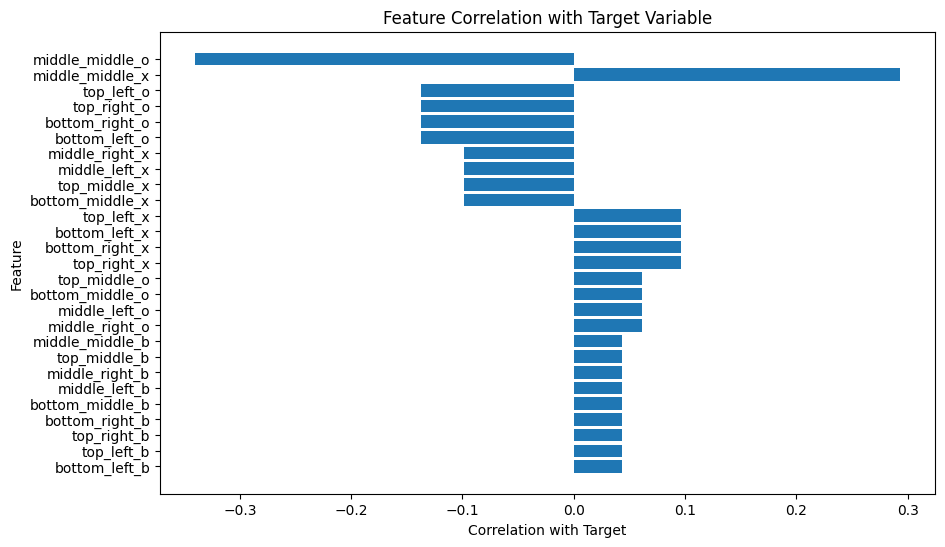

In [104]:
# Visualize the correlations
plt.figure(figsize=(10, 6))
plt.barh(correlation_df['Feature'], correlation_df['Correlation'])
plt.xlabel('Correlation with Target')
plt.ylabel('Feature')
plt.title('Feature Correlation with Target Variable')
plt.gca().invert_yaxis()
plt.show()
# plt.savefig('1_Correlation_graph.png')

# Without stratify

## Train-test split

In [105]:
X_train_without, X_test_without, y_train_without, y_test_without = train_test_split(X, y, test_size=0.3, train_size=0.7, random_state=42)

## Instantiate

In [106]:
clf_without = DecisionTreeClassifier(criterion ='entropy')

## Train

In [107]:
clf_without.fit(X_train_without, y_train_without)

DecisionTreeClassifier(criterion='entropy')

## Predict

In [108]:
y_pred_without = clf_without.predict(X_test_without)
y_pred_without

array(['negative', 'positive', 'positive', 'negative', 'negative',
       'positive', 'positive', 'positive', 'positive', 'negative',
       'positive', 'positive', 'positive', 'negative', 'positive',
       'positive', 'negative', 'positive', 'negative', 'negative',
       'negative', 'positive', 'negative', 'positive', 'negative',
       'positive', 'positive', 'positive', 'negative', 'positive',
       'positive', 'positive', 'positive', 'positive', 'negative',
       'negative', 'positive', 'negative', 'positive', 'negative',
       'positive', 'positive', 'negative', 'negative', 'negative',
       'positive', 'positive', 'positive', 'negative', 'negative',
       'negative', 'negative', 'positive', 'positive', 'negative',
       'positive', 'positive', 'negative', 'negative', 'positive',
       'positive', 'positive', 'negative', 'positive', 'positive',
       'positive', 'positive', 'negative', 'positive', 'positive',
       'negative', 'negative', 'negative', 'positive', 'positi

## Evaluate

In [109]:
for pred, true in zip(y_pred_without, y_test_without):
    print(f"Predicted: {pred} and Ground: {true}") 

Predicted: negative and Ground: negative
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: negative and Ground: negative
Predicted: negative and Ground: negative
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: negative and Ground: negative
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: negative and Ground: negative
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: negative and Ground: positive
Predicted: positive and Ground: positive
Predicted: negative and Ground: negative
Predicted: negative and Ground: negative
Predicted: negative and Ground: negative
Predicted: positive and Ground: positive
Predicted: negative and Ground: negative
Predicted: positive and Ground: positive
Predicted: negat

### Classification Report

In [110]:
report = classification_report(y_test_without, y_pred_without)
print("Before Stratification")
print(report)

Before Stratification
              precision    recall  f1-score   support

    negative       0.90      0.94      0.92        95
    positive       0.97      0.95      0.96       193

    accuracy                           0.94       288
   macro avg       0.93      0.94      0.94       288
weighted avg       0.95      0.94      0.94       288



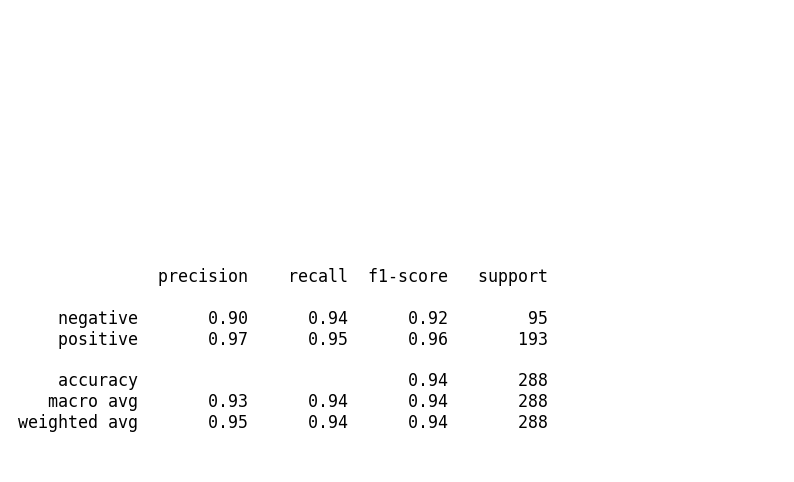

In [111]:
# Create a plot and add the classification report text
plt.figure(figsize=(10, 6))
plt.text(0.01, 0.05, str(report), {'fontsize': 12}, fontproperties='monospace')  # use monospaced font
plt.axis('off')
plt.show()

In [112]:
# Calculate F1 score
f1_without = f1_score(y_test_without, y_pred_without, pos_label='positive')

# Calculate accuracy
accuracy_without = accuracy_score(y_test_without, y_pred_without)

# Calculate precision
precision_without = precision_score(y_test_without, y_pred_without, pos_label='positive')

# Calculate recall
recall_without = recall_score(y_test_without, y_pred_without, pos_label='positive')

print("F1 Score:", f1_without)
print("Accuracy:", accuracy_without)
print("Precision:", precision_without)
print("Recall:",recall_without)

F1 Score: 0.9581151832460733
Accuracy: 0.9444444444444444
Precision: 0.9682539682539683
Recall: 0.9481865284974094


### Confusion Matrix

In [113]:
confusion_mat_without = confusion_matrix(y_test_without, y_pred_without)

In [114]:
confusion_df = pd.DataFrame(confusion_mat_without, index=['No', 'Yes'],columns=['No','Yes'])

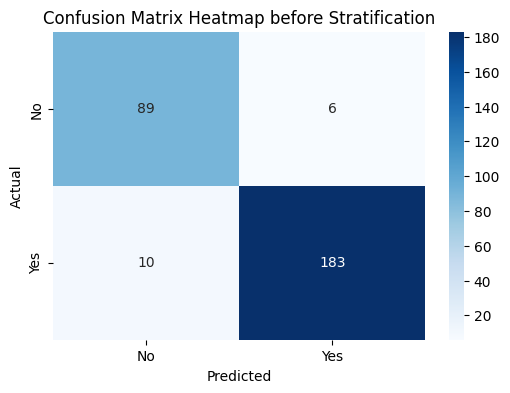

In [115]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_df, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap before Stratification')
# plt.savefig('2_confusion_matrix_without_stratify.png',dpi=600)  # Save the plot as an image
plt.show()

### F1 Score

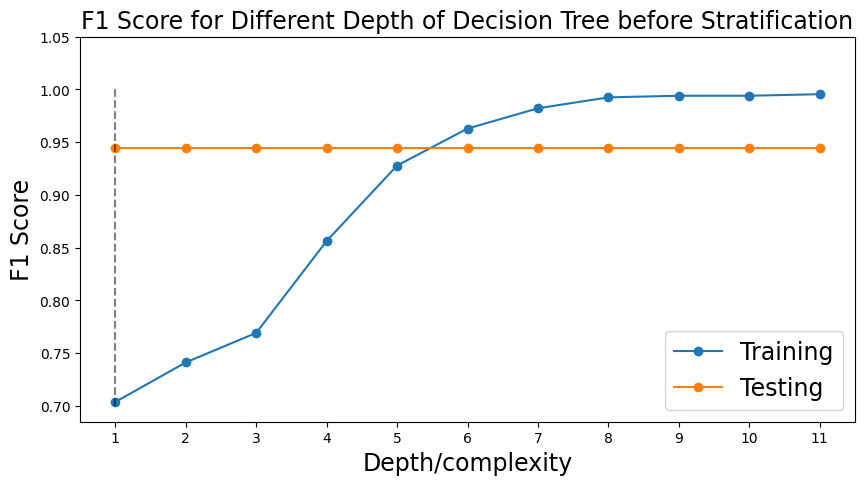

In [116]:
train_scores = []
test_socres = []
for i in range(1, clf_without.get_depth()+1):
    model = DecisionTreeClassifier(random_state=42, max_depth=i).fit(X_train_without, y_train_without)

    # Computing f1_score in train set
    y_pred_train = model.predict(X_train_without)
    train_scores.append(f1_score(y_pred_train, y_train_without, average='weighted'))# f1_score on train set

    # Computing f1_score on test set
    y_pred = model.predict(X_test_without) # Making Predictions
    test_socres.append(f1_score(y_test_without, y_pred_without, average='weighted'))

max_test_score = np.argmax(test_socres) + 1
# Plot of depth vs accuracy
depth = clf_without.get_depth()
plt.figure(figsize = (10,5))
plt.plot(np.arange(1, depth+1, 1), train_scores, marker = 'o', label = 'Training')
plt.plot(np.arange(1, depth+1, 1), test_socres, marker = 'o', label = "Testing")
plt.plot([max_test_score,max_test_score], [0.7, 1.0], '--', color = 'black', alpha = 0.5)
plt.xlabel("Depth/complexity", fontsize = 17)
plt.ylabel("F1 Score", fontsize = 17)
plt.title("F1 Score for Different Depth of Decision Tree before Stratification", fontsize = 17)
plt.xticks(np.arange(1, depth+1, 1))
plt.yticks(np.arange(0.7, 1.05, 0.05))
plt.legend(fontsize = 17)
plt.show()
# plt.savefig('3_F1_score_comparison_before_stratify.png',dpi=600)  # Save the plot as an image

### ROC Curve

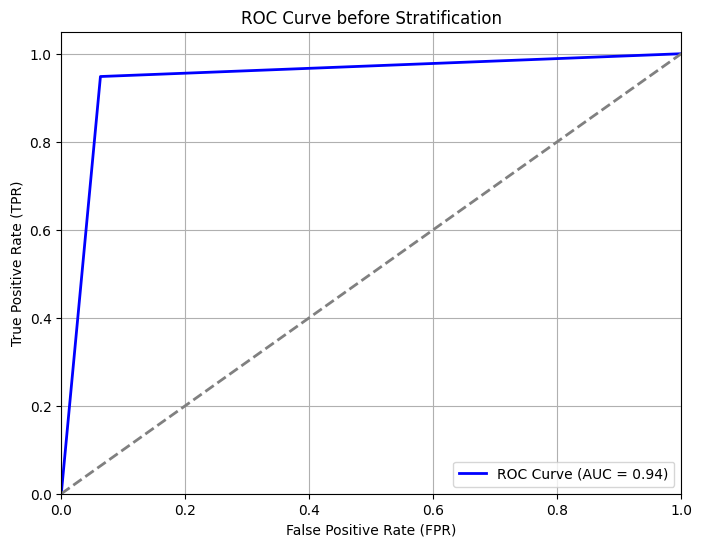

In [117]:
# Predict probabilities for the positive class (class 1)
y_scores_without = clf_without.predict_proba(X_test_without)[:, 1]

# Assuming 'negative' is mapped to 0 and 'positive' is mapped to 1
y_test_without_binary = np.where(y_test_without == 'positive', 1, 0)

# Compute ROC curve and ROC area for each class
fpr_without, tpr_without, _ = roc_curve(y_test_without_binary, y_scores_without)
roc_auc_without = auc(fpr_without, tpr_without)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_without, tpr_without, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc_without:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve before Stratification')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
# plt.savefig('4_ROC_curve_before_stratify.png', dpi=600)

## Tree Visualization

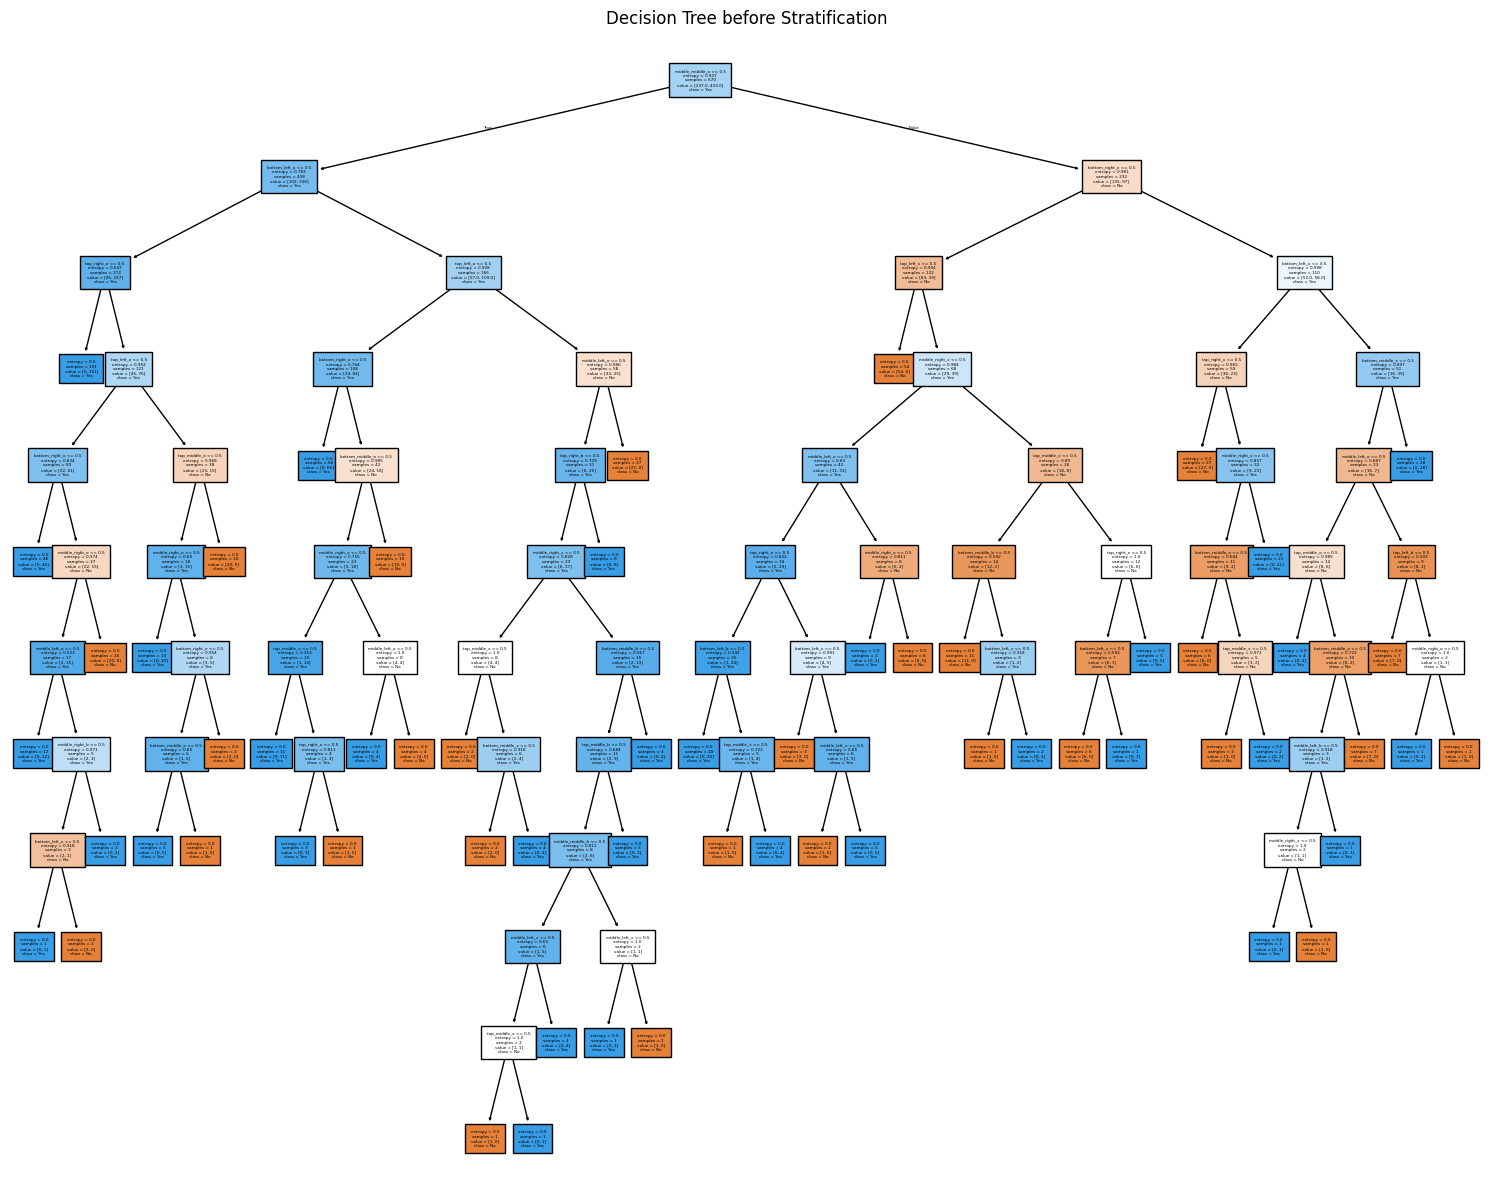

In [118]:
plt.figure(figsize=(19, 15))
tree.plot_tree(clf_without, feature_names=X.columns, class_names=['No', 'Yes'], filled=True, fontsize =3)
plt.title('Decision Tree before Stratification')
# plt.savefig('5_decision_tree_before_stratification.png', dpi=600)  # Save the plot as an image
plt.show()

# Check for imbalanced data

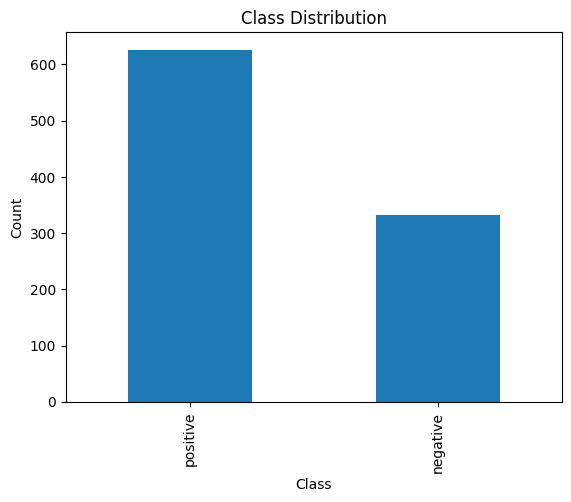

In [119]:
df['class'].value_counts().plot(kind='bar')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()
# plt.savefig('2_Class_distribution.png', dpi=600)

In [120]:
#Contains imbalanced data

In [121]:
# X_train.shape, X_test.shape, y_train.shape, y_test.shape

# With stratify

## Train-test split

In [122]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, train_size=0.7, random_state=42)

## Entropy

### Initialize

In [123]:
clf_entropy = DecisionTreeClassifier(criterion ='entropy')

### Train

In [124]:
clf_entropy.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

### Predict

In [125]:
y_pred_entropy = clf_entropy.predict(X_test)
y_pred_entropy

array(['positive', 'positive', 'positive', 'negative', 'positive',
       'negative', 'negative', 'positive', 'positive', 'negative',
       'positive', 'positive', 'negative', 'positive', 'positive',
       'negative', 'positive', 'positive', 'negative', 'positive',
       'positive', 'negative', 'positive', 'positive', 'positive',
       'positive', 'negative', 'positive', 'negative', 'positive',
       'negative', 'negative', 'positive', 'negative', 'positive',
       'positive', 'positive', 'positive', 'negative', 'positive',
       'negative', 'positive', 'negative', 'positive', 'positive',
       'positive', 'negative', 'positive', 'positive', 'positive',
       'negative', 'positive', 'negative', 'positive', 'negative',
       'negative', 'negative', 'positive', 'positive', 'positive',
       'positive', 'positive', 'positive', 'positive', 'negative',
       'positive', 'positive', 'positive', 'positive', 'negative',
       'positive', 'positive', 'positive', 'negative', 'negati

### Evaluate

In [126]:
for pred, true in zip(y_pred_entropy, y_test):
    print(f"Predicted: {pred} and Ground: {true}") 

Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: negative and Ground: negative
Predicted: positive and Ground: positive
Predicted: negative and Ground: negative
Predicted: negative and Ground: negative
Predicted: positive and Ground: positive
Predicted: positive and Ground: negative
Predicted: negative and Ground: positive
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: negative and Ground: positive
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: negative and Ground: negative
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: negative and Ground: negative
Predicted: positive and Ground: positive
Predicted: positive and Ground: negative
Predicted: negative and Ground: negative
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: posit

#### Confusion Matrix

In [127]:
confusion_mat_entropy = confusion_matrix(y_test, y_pred_entropy)
print(confusion_mat_entropy)

[[ 86  14]
 [ 14 174]]


In [128]:
confusion_df_entropy = pd.DataFrame(confusion_mat_entropy, index=['No', 'Yes'],columns=['No','Yes'])

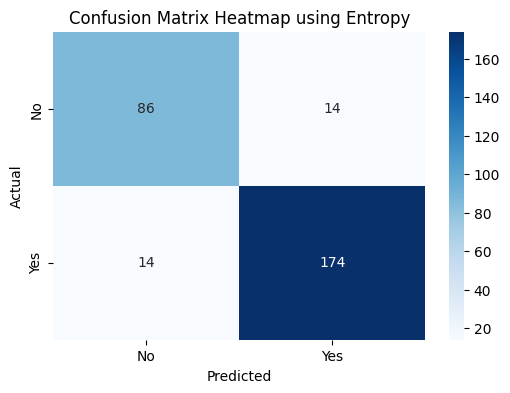

In [129]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_df_entropy, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap using Entropy')
plt.savefig('3_confusion_matrix_using_entropy.png',dpi=600)  # Save the plot as an image
plt.show()

#### Classification Report

In [130]:
report_entropy = classification_report(y_test, y_pred_entropy)
print("Classification Report After Stratify (Entropy)")
print(report_entropy)

Classification Report After Stratify (Entropy)
              precision    recall  f1-score   support

    negative       0.86      0.86      0.86       100
    positive       0.93      0.93      0.93       188

    accuracy                           0.90       288
   macro avg       0.89      0.89      0.89       288
weighted avg       0.90      0.90      0.90       288



In [131]:
# Calculate F1 score
f1_entropy = f1_score(y_test, y_pred_entropy, pos_label='positive')

# Calculate accuracy
accuracy_entropy = accuracy_score(y_test, y_pred_entropy)

# Calculate precision
precision_entropy = precision_score(y_test, y_pred_entropy, pos_label='positive')

# Calculate recall
recall_entropy = recall_score(y_test, y_pred_entropy, pos_label='positive')

print("F1 Score:", f1_entropy)
print("Accuracy:", accuracy_entropy)
print("Precision:", precision_entropy)
print("Recall:",recall_entropy)

F1 Score: 0.925531914893617
Accuracy: 0.9027777777777778
Precision: 0.925531914893617
Recall: 0.925531914893617


#### F1 Score

In [132]:
y_pred_train_entropy = clf_entropy.predict(X_train)
train_f1_score_entropy = f1_score(y_train, y_pred_train_entropy, average='weighted')
test_f1_score_entropy = f1_score(y_test, y_pred_entropy, average='weighted')

print('Train F1 score = ')
print(train_f1_score_entropy)
print('Test F1 score = ')
print(test_f1_score_entropy)

Train F1 score = 
1.0
Test F1 score = 
0.9027777777777778


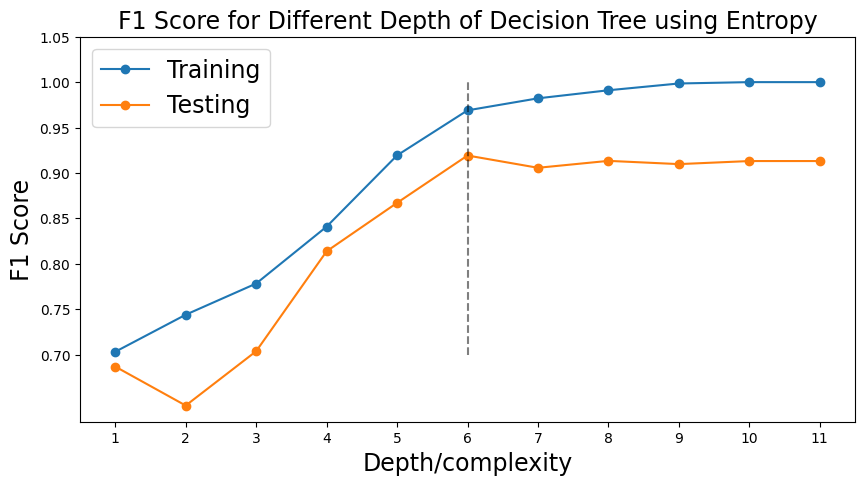

In [133]:
import matplotlib.pyplot as plt
%matplotlib inline


train_scores = []
test_socres = []
for i in range(1, clf_entropy.get_depth()+1):
    model = DecisionTreeClassifier(random_state=42, max_depth=i).fit(X_train, y_train)

    # Computing f1_score in train set
    y_pred_train = model.predict(X_train)
    train_scores.append(f1_score(y_pred_train, y_train, average='weighted'))# f1_score on train set

    # Computing f1_score on test set
    y_pred = model.predict(X_test) # Making Predictions
    test_socres.append(f1_score(y_test, y_pred, average='weighted'))

max_test_score = np.argmax(test_socres) + 1
# Plot of depth vs accuracy
depth = clf_entropy.get_depth()
plt.figure(figsize = (10,5))
plt.plot(np.arange(1, depth+1, 1), train_scores, marker = 'o', label = 'Training')
plt.plot(np.arange(1, depth+1, 1), test_socres, marker = 'o', label = "Testing")
plt.plot([max_test_score,max_test_score], [0.7, 1.0], '--', color = 'black', alpha = 0.5)
plt.xlabel("Depth/complexity", fontsize = 17)
plt.ylabel("F1 Score", fontsize = 17)
plt.title("F1 Score for Different Depth of Decision Tree using Entropy", fontsize = 17)
plt.xticks(np.arange(1, depth+1, 1))
plt.yticks(np.arange(0.7, 1.05, 0.05))
plt.legend(fontsize = 17)
plt.show()

#### ROC Curve

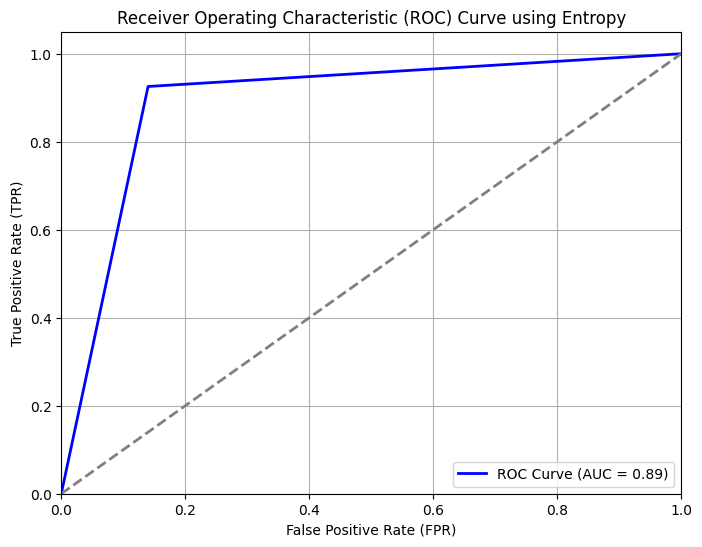

In [134]:
# Predict probabilities for the positive class (class 1)
y_scores_entropy = clf_entropy.predict_proba(X_test)[:, 1]

# Assuming 'negative' is mapped to 0 and 'positive' is mapped to 1
y_test_entropy_binary = np.where(y_test == 'positive', 1, 0)

# Compute ROC curve and ROC area for each class
fpr_entropy, tpr_entropy, _ = roc_curve(y_test_entropy_binary, y_scores_entropy)
roc_auc_entropy = auc(fpr_entropy, tpr_entropy)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_entropy, tpr_entropy, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc_entropy:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve using Entropy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Tree Visualization

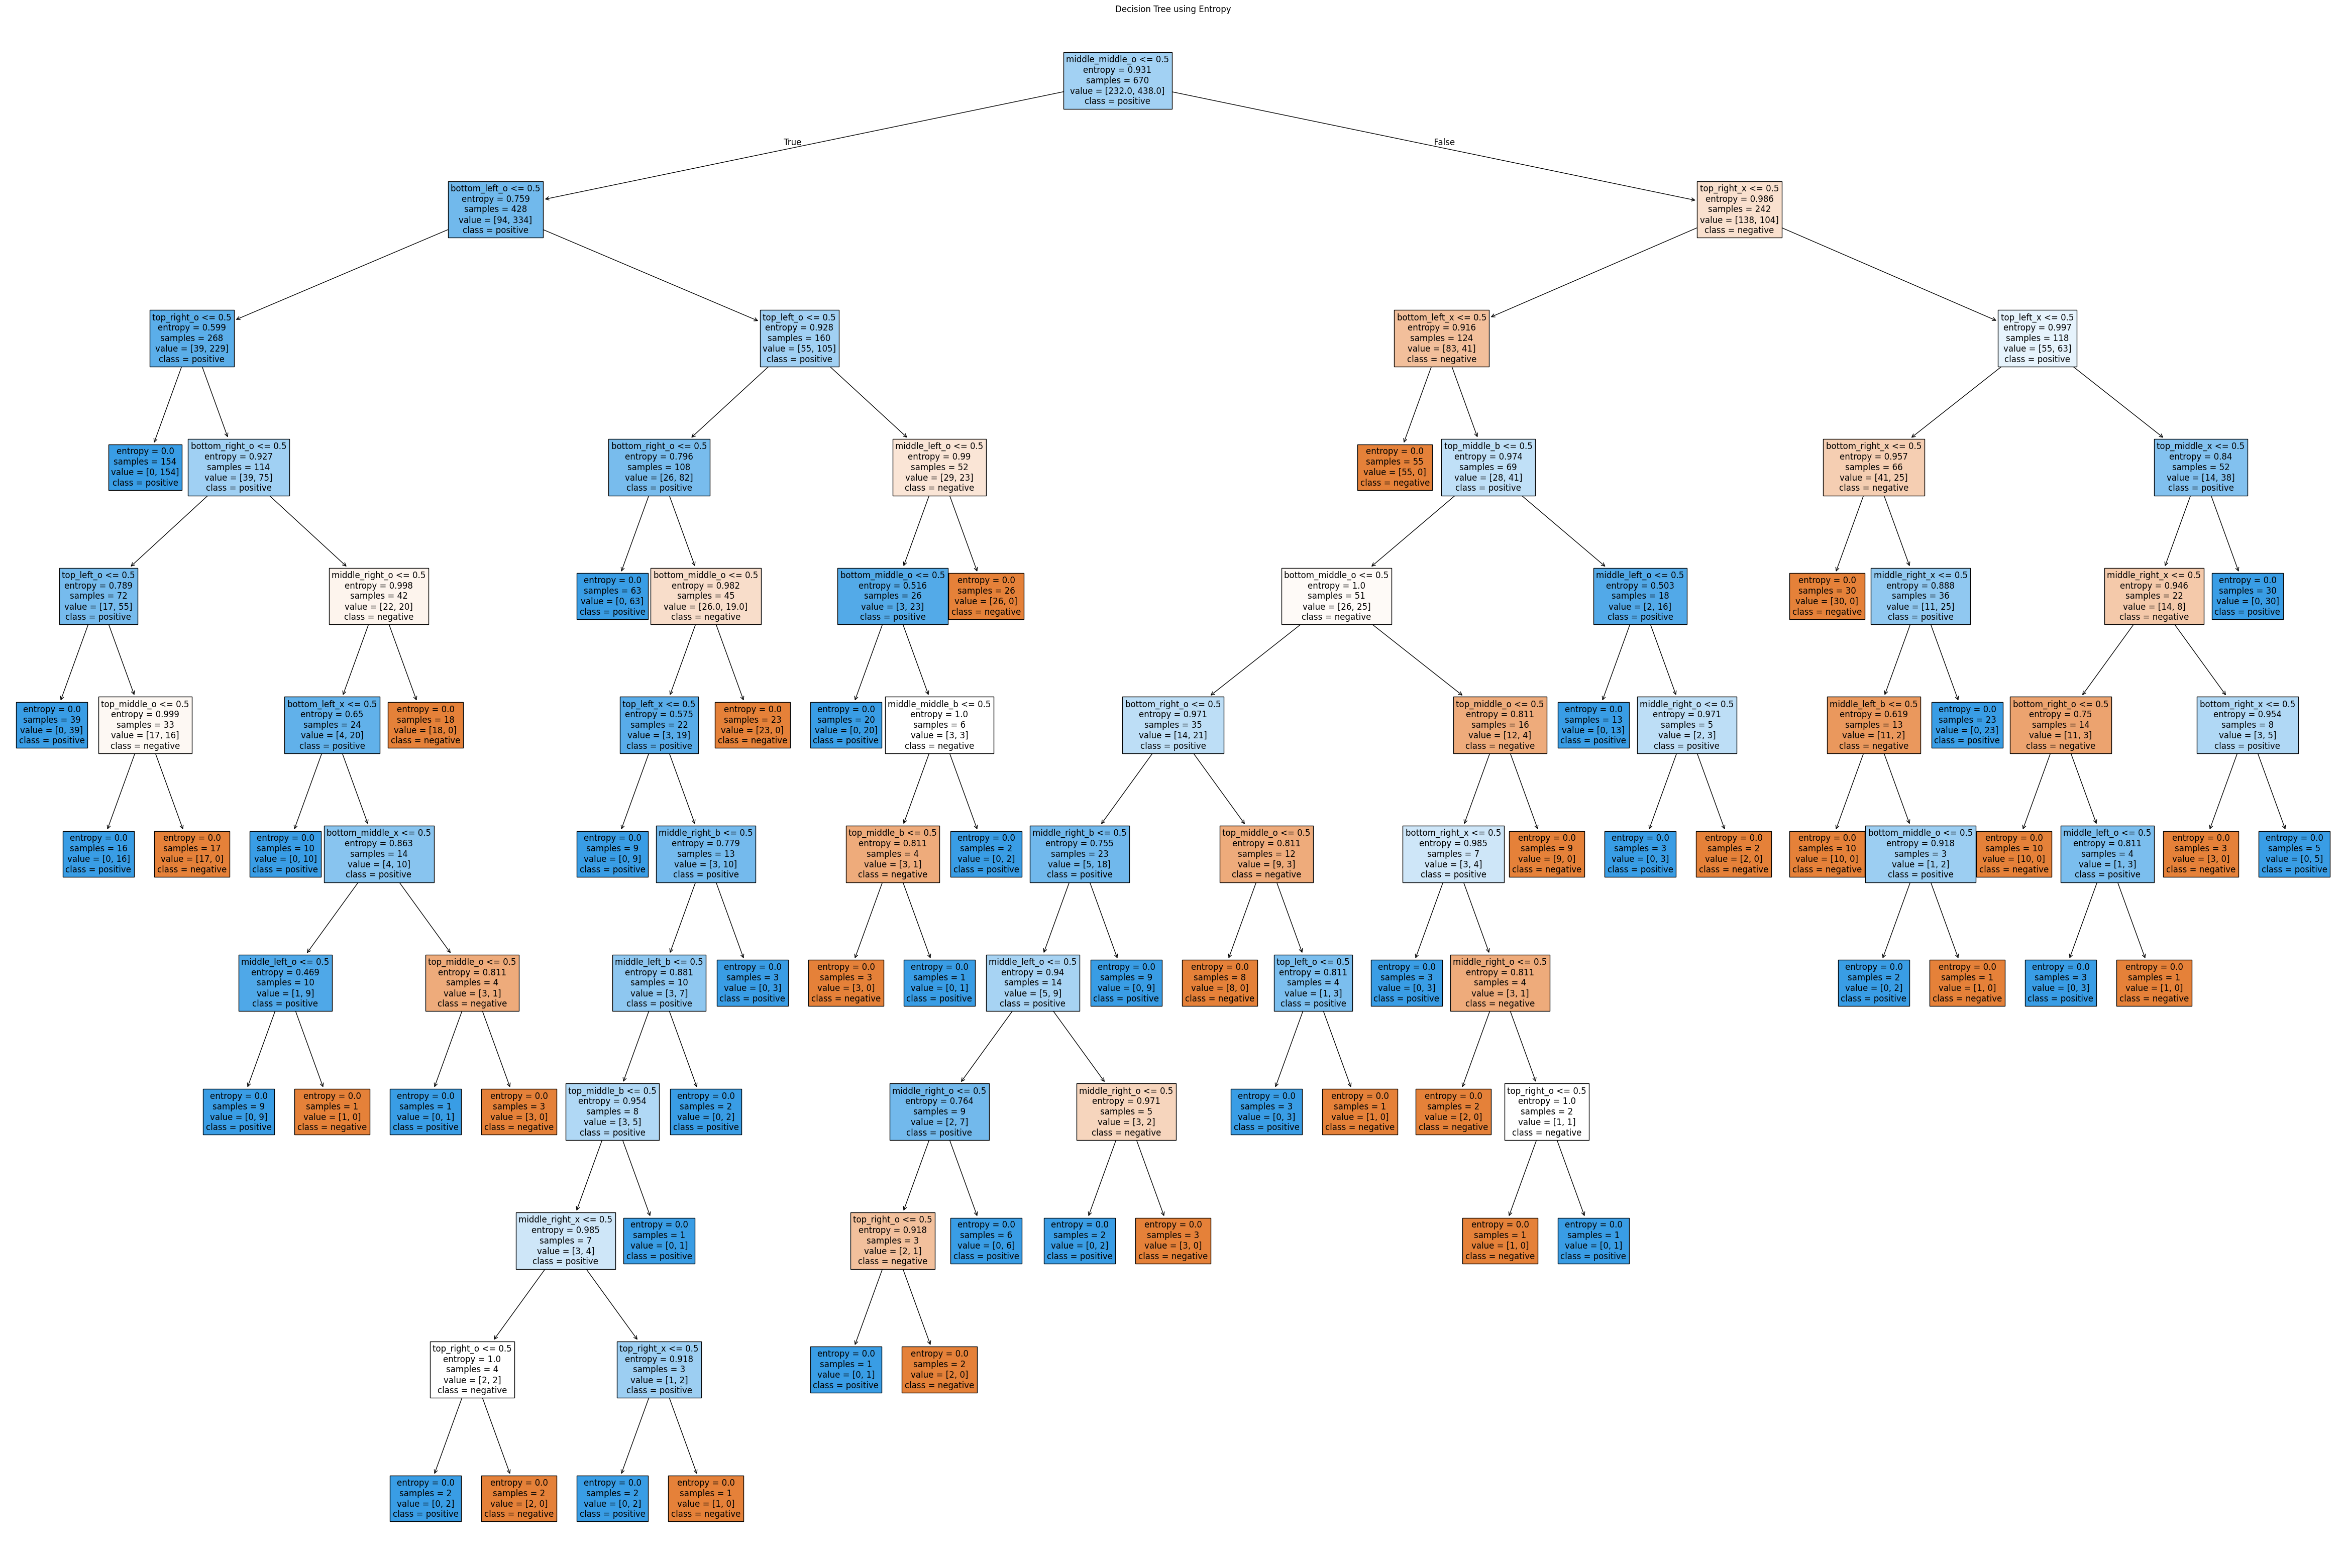

In [135]:
plt.figure(figsize=(60, 40))
tree.plot_tree(clf_entropy, feature_names=X.columns, class_names=['negative', 'positive'], filled=True, fontsize =12)
plt.title('Decision Tree using Entropy')
plt.savefig('depth17.png', dpi=300)  # Save the plot as an image
plt.show()

## GINI

### Initialize

In [136]:
depth = 6
clf_gini = DecisionTreeClassifier(criterion ='gini', max_depth = 6)

### Train

In [137]:
clf_gini.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6)

### Predict

In [138]:
y_pred_gini = clf_gini.predict(X_test)
y_pred_gini

array(['positive', 'positive', 'positive', 'negative', 'positive',
       'negative', 'negative', 'positive', 'positive', 'positive',
       'positive', 'positive', 'negative', 'positive', 'positive',
       'negative', 'positive', 'positive', 'negative', 'positive',
       'positive', 'negative', 'positive', 'positive', 'positive',
       'positive', 'negative', 'positive', 'negative', 'positive',
       'negative', 'negative', 'positive', 'negative', 'positive',
       'positive', 'positive', 'positive', 'negative', 'positive',
       'negative', 'positive', 'negative', 'positive', 'positive',
       'positive', 'negative', 'positive', 'positive', 'positive',
       'negative', 'positive', 'negative', 'positive', 'negative',
       'positive', 'negative', 'positive', 'positive', 'positive',
       'positive', 'positive', 'positive', 'positive', 'negative',
       'positive', 'positive', 'positive', 'positive', 'negative',
       'positive', 'positive', 'positive', 'negative', 'negati

### Evaluate

In [139]:
for pred, true in zip(y_pred_gini, y_test):
    print(f"Predicted: {pred} and Ground: {true}") 

Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: negative and Ground: negative
Predicted: positive and Ground: positive
Predicted: negative and Ground: negative
Predicted: negative and Ground: negative
Predicted: positive and Ground: positive
Predicted: positive and Ground: negative
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: negative and Ground: positive
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: negative and Ground: negative
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: negative and Ground: negative
Predicted: positive and Ground: positive
Predicted: positive and Ground: negative
Predicted: negative and Ground: negative
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: posit

#### Confusion Matrix

In [140]:
confusion_mat_gini = confusion_matrix(y_test, y_pred_gini)
print(confusion_mat_gini)

[[ 84  16]
 [  9 179]]


In [141]:
confusion_df_gini = pd.DataFrame(confusion_mat_gini, index=['No', 'Yes'],columns=['No','Yes'])

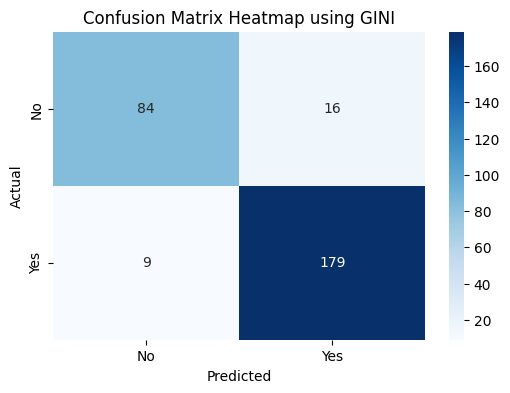

In [142]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_df_gini, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap using GINI')
# plt.savefig('confusion_matrix_maxdepth17.png',dpi=200)  # Save the plot as an image
plt.show()

#### Classification Report

In [143]:
report_gini = classification_report(y_test, y_pred_gini)
print("Classification report using gini")
print(report_gini)

Classification report using gini
              precision    recall  f1-score   support

    negative       0.90      0.84      0.87       100
    positive       0.92      0.95      0.93       188

    accuracy                           0.91       288
   macro avg       0.91      0.90      0.90       288
weighted avg       0.91      0.91      0.91       288



In [144]:
# Calculate F1 score
f1_gini = f1_score(y_test, y_pred_gini, pos_label='positive')

# Calculate accuracy
accuracy_gini = accuracy_score(y_test, y_pred_gini)

# Calculate precision
precision_gini = precision_score(y_test, y_pred_gini, pos_label='positive')

# Calculate recall
recall_gini = recall_score(y_test, y_pred_gini, pos_label='positive')

print("F1 Score:", f1_gini)
print("Accuracy:", accuracy_gini)
print("Precision:", precision_gini)
print("Recall:",recall_gini)

F1 Score: 0.9347258485639687
Accuracy: 0.9131944444444444
Precision: 0.9179487179487179
Recall: 0.9521276595744681


#### F1 Score

In [145]:
y_pred_train_gini = clf_gini.predict(X_train)
train_f1_score_gini = f1_score(y_train, y_pred_train_gini, average='weighted')
test_f1_score_gini = f1_score(y_test, y_pred_gini, average='weighted')

print('Train F1 score = ')
print(train_f1_score_gini)
print('Test F1 score = ')
print(test_f1_score_gini)

Train F1 score = 
0.9684341530644871
Test F1 score = 
0.9124135126888141


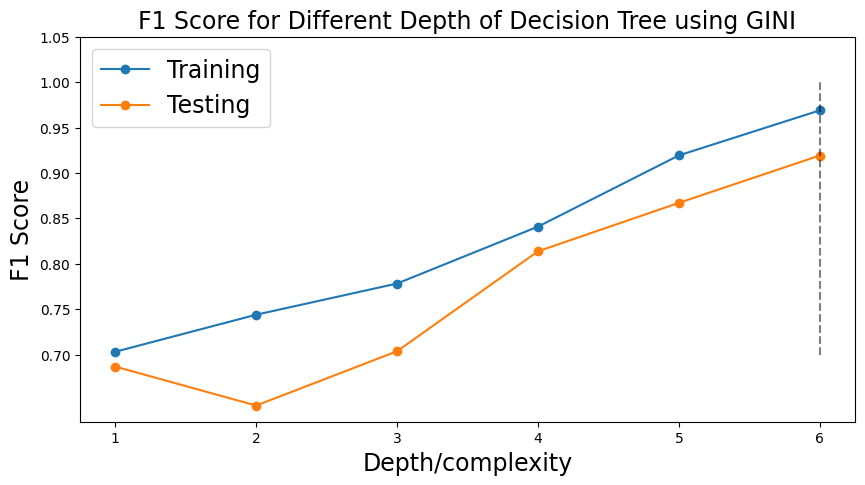

In [146]:
train_scores_gini = []
test_scores_gini = []
for i in range(1, clf_gini.get_depth()+1):
    model = DecisionTreeClassifier(random_state=42, max_depth=i).fit(X_train, y_train)

    # Computing f1_score in train set
    y_pred_train_gini = model.predict(X_train)
    train_scores_gini.append(f1_score(y_pred_train_gini, y_train, average='weighted'))# f1_score on train set

    # Computing f1_score on test set
    y_pred_gini = model.predict(X_test) # Making Predictions
    test_scores_gini.append(f1_score(y_test, y_pred_gini, average='weighted'))

max_test_score_gini = np.argmax(test_socres) + 1
# Plot of depth vs accuracy
depth = clf_gini.get_depth()
plt.figure(figsize = (10,5))
plt.plot(np.arange(1, depth+1, 1), train_scores_gini, marker = 'o', label = 'Training')
plt.plot(np.arange(1, depth+1, 1), test_scores_gini, marker = 'o', label = "Testing")
plt.plot([max_test_score_gini,max_test_score_gini], [0.7, 1.0], '--', color = 'black', alpha = 0.5)
plt.xlabel("Depth/complexity", fontsize = 17)
plt.ylabel("F1 Score", fontsize = 17)
plt.title("F1 Score for Different Depth of Decision Tree using GINI", fontsize = 17)
plt.xticks(np.arange(1, depth+1, 1))
plt.yticks(np.arange(0.7, 1.05, 0.05))
plt.legend(fontsize = 17)
plt.show()

#### ROC Curve

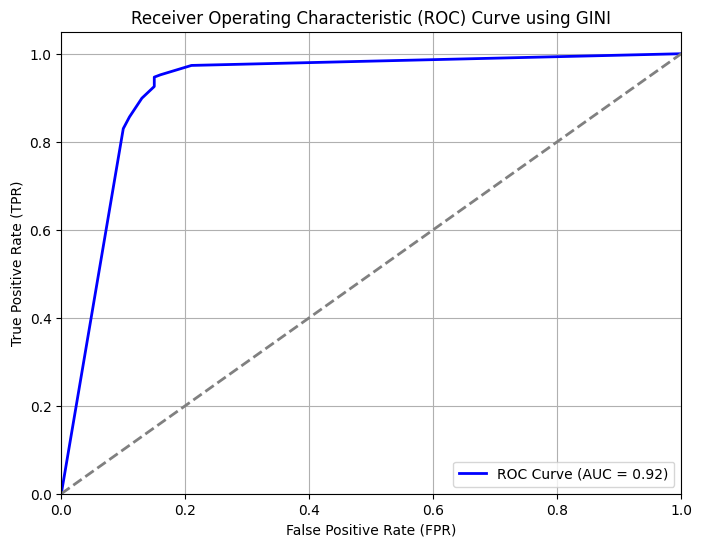

In [147]:
# Predict probabilities for the positive class (class 1)
y_scores_gini = clf_gini.predict_proba(X_test)[:, 1]

# Assuming 'negative' is mapped to 0 and 'positive' is mapped to 1
y_test_gini_binary = np.where(y_test == 'positive', 1, 0)

# Compute ROC curve and ROC area for each class
fpr_gini, tpr_gini, _ = roc_curve(y_test_gini_binary, y_scores_gini)
roc_auc_gini = auc(fpr_gini, tpr_gini)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_gini, tpr_gini, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc_gini:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve using GINI')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Visualize

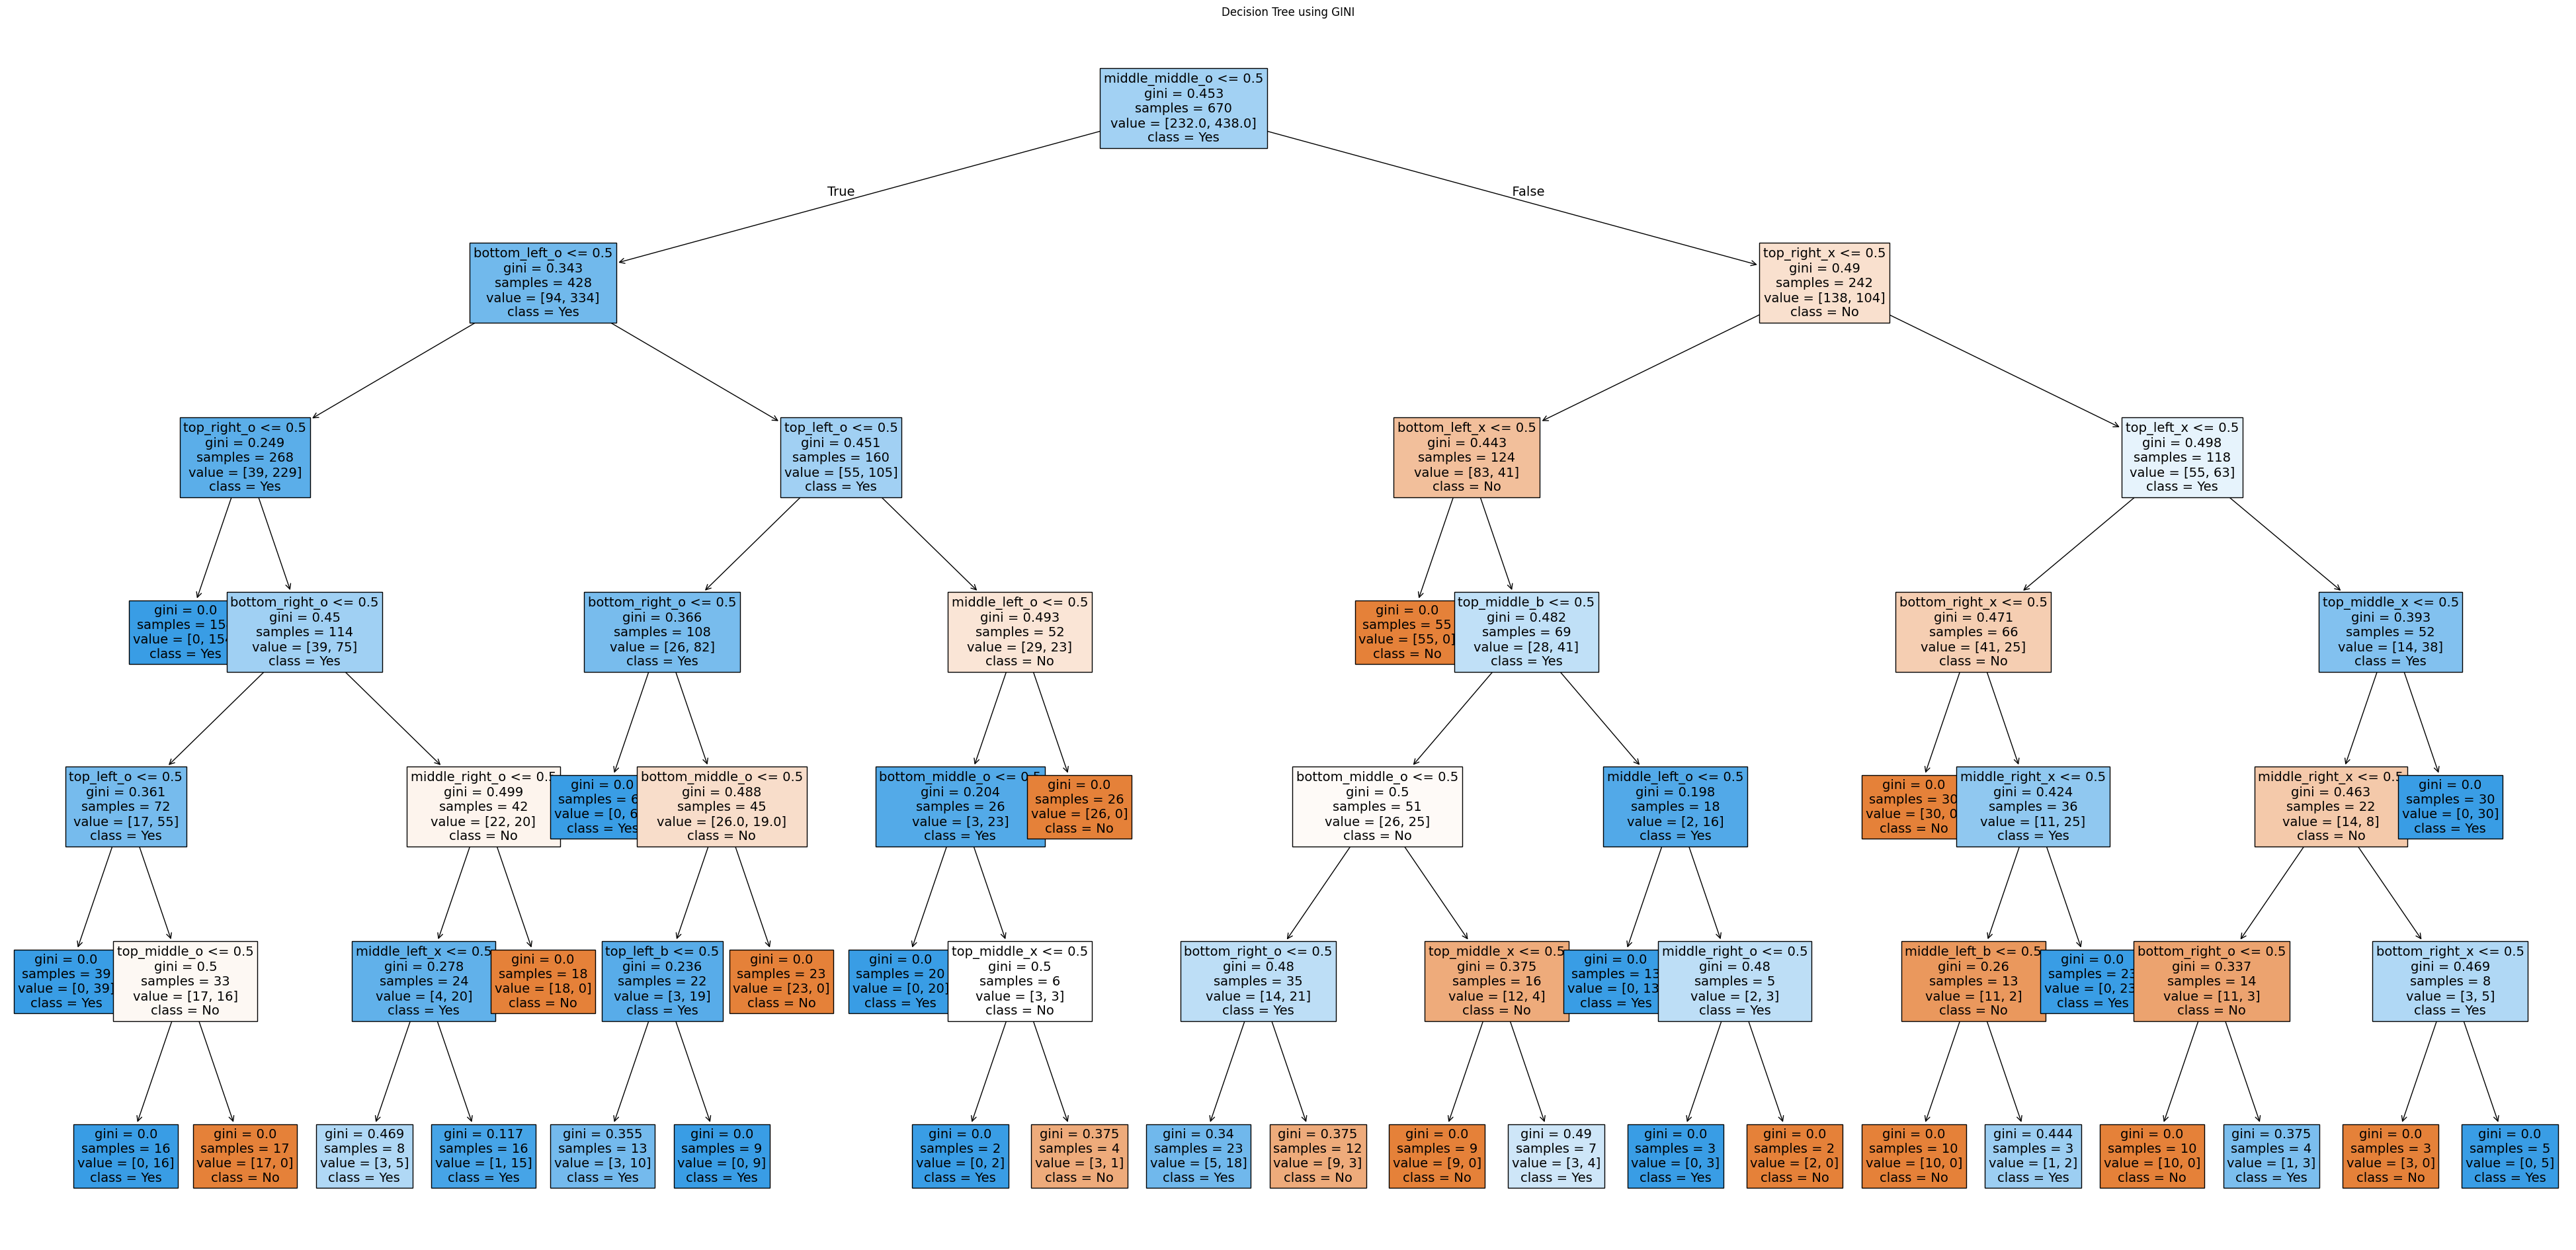

In [194]:
plt.figure(figsize=(50, 24))
tree.plot_tree(clf_gini, feature_names=X.columns, class_names=['No', 'Yes'], filled=True, fontsize =14)
plt.title('Decision Tree using GINI')
plt.savefig('GINI.png', dpi=600)  # Save the plot as an image
plt.show()

# Depth Pruning/Early Stopping

In [149]:
max_depth = 3
clf_dp = DecisionTreeClassifier(criterion='entropy', max_depth=max_depth)

In [150]:
clf_dp.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

In [151]:
y_pred_dp = clf_dp.predict(X_test)
y_pred_dp

array(['positive', 'positive', 'positive', 'negative', 'positive',
       'positive', 'positive', 'positive', 'positive', 'positive',
       'positive', 'positive', 'positive', 'positive', 'positive',
       'negative', 'positive', 'positive', 'negative', 'positive',
       'positive', 'negative', 'negative', 'positive', 'positive',
       'positive', 'negative', 'positive', 'negative', 'positive',
       'positive', 'negative', 'positive', 'negative', 'positive',
       'positive', 'positive', 'positive', 'positive', 'negative',
       'positive', 'negative', 'positive', 'positive', 'positive',
       'positive', 'positive', 'positive', 'positive', 'positive',
       'positive', 'positive', 'negative', 'positive', 'negative',
       'positive', 'negative', 'positive', 'positive', 'positive',
       'positive', 'positive', 'positive', 'positive', 'positive',
       'positive', 'positive', 'positive', 'positive', 'negative',
       'positive', 'positive', 'negative', 'negative', 'negati

In [152]:
for pred, true in zip(y_pred_dp, y_test):
    print(f"Predicted: {pred} and Ground: {true}") 

Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: negative and Ground: negative
Predicted: positive and Ground: positive
Predicted: positive and Ground: negative
Predicted: positive and Ground: negative
Predicted: positive and Ground: positive
Predicted: positive and Ground: negative
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: negative and Ground: negative
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: negative and Ground: negative
Predicted: positive and Ground: positive
Predicted: positive and Ground: negative
Predicted: negative and Ground: negative
Predicted: negative and Ground: positive
Predicted: positive and Ground: positive
Predicted: posit

In [153]:
confusion_mat_dp = confusion_matrix(y_test, y_pred_dp)
print(confusion_mat_dp)

[[ 44  56]
 [ 25 163]]


In [154]:
confusion_df_dp = pd.DataFrame(confusion_mat_dp, index=['No', 'Yes'],columns=['No','Yes'])

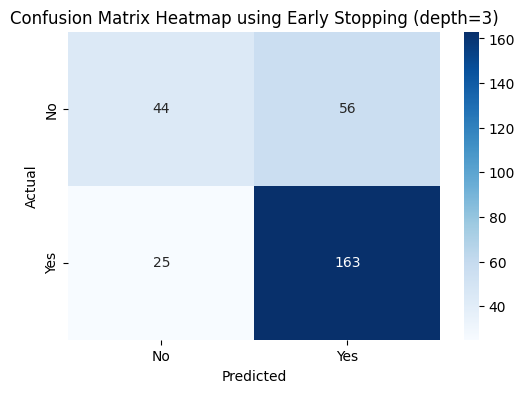

In [155]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_df_dp, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap using Early Stopping (depth=3)')
# plt.savefig('confusion_matrix_maxdepth17.png',dpi=200)  # Save the plot as an image
plt.show()

In [156]:
report_dp = classification_report(y_test, y_pred_dp)
print("Classification report using early stopping (e, optimal depth=6)")
print(report_dp)

Classification report using early stopping (e, optimal depth=6)
              precision    recall  f1-score   support

    negative       0.64      0.44      0.52       100
    positive       0.74      0.87      0.80       188

    accuracy                           0.72       288
   macro avg       0.69      0.65      0.66       288
weighted avg       0.71      0.72      0.70       288



In [157]:
# Calculate F1 score
f1_dp = f1_score(y_test, y_pred_dp, pos_label='positive')

# Calculate accuracy
accuracy_dp = accuracy_score(y_test, y_pred_dp)

# Calculate precision
precision_dp = precision_score(y_test, y_pred_dp, pos_label='positive')

# Calculate recall
recall_dp = recall_score(y_test, y_pred_dp, pos_label='positive')

print("F1 Score:", f1_dp)
print("Accuracy:", accuracy_dp)
print("Precision:", precision_dp)
print("Recall:",recall_dp)

F1 Score: 0.800982800982801
Accuracy: 0.71875
Precision: 0.7442922374429224
Recall: 0.8670212765957447


In [158]:
y_pred_train_dp = clf_dp.predict(X_train)
train_f1_score_dp = f1_score(y_train, y_pred_train_dp, average='weighted')
test_f1_score_dp = f1_score(y_test, y_pred_dp, average='weighted')

print('Train F1 score = ')
print(train_f1_score_dp)
print('Test F1 score = ')
print(test_f1_score_dp)

Train F1 score = 
0.7591048520518816
Test F1 score = 
0.7036658767427998


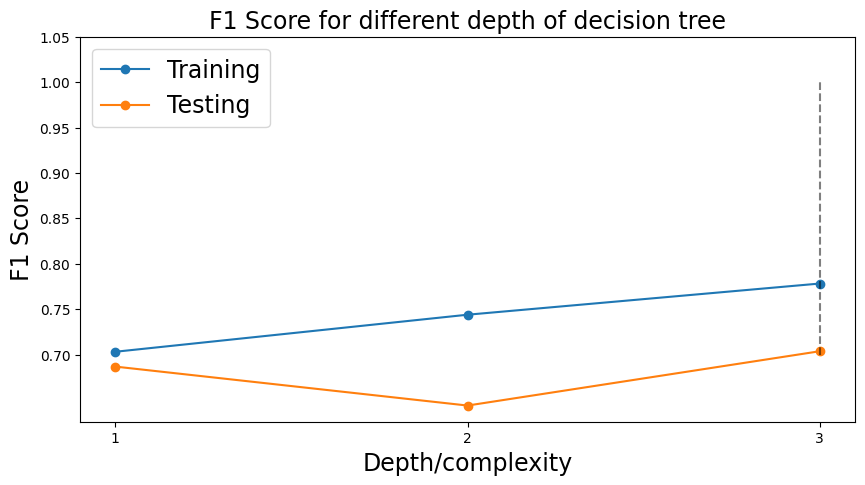

In [159]:
train_scores_dp = []
test_scores_dp = []
for i in range(1, clf_dp.get_depth()+1):
    model_dp = DecisionTreeClassifier(random_state=42, max_depth=i).fit(X_train, y_train)

    # Computing f1_score in train set
    y_pred_train_dp = model_dp.predict(X_train)
    train_scores_dp.append(f1_score(y_pred_train_dp, y_train, average='weighted'))# f1_score on train set

    # Computing f1_score on test set
    y_pred_dp = model_dp.predict(X_test) # Making Predictions
    test_scores_dp.append(f1_score(y_test, y_pred_dp, average='weighted'))

max_test_score_dp = np.argmax(test_scores_dp) + 1
# Plot of depth vs accuracy
depth = clf_dp.get_depth()
plt.figure(figsize = (10,5))
plt.plot(np.arange(1, depth+1, 1), train_scores_dp, marker = 'o', label = 'Training')
plt.plot(np.arange(1, depth+1, 1), test_scores_dp, marker = 'o', label = "Testing")
plt.plot([max_test_score_dp, max_test_score_dp], [0.7, 1.0], '--', color = 'black', alpha = 0.5)
plt.xlabel("Depth/complexity", fontsize = 17)
plt.ylabel("F1 Score", fontsize = 17)
plt.title("F1 Score for different depth of decision tree", fontsize = 17)
plt.xticks(np.arange(1, depth+1, 1))
plt.yticks(np.arange(0.7, 1.05, 0.05))
plt.legend(fontsize = 17)
plt.show()

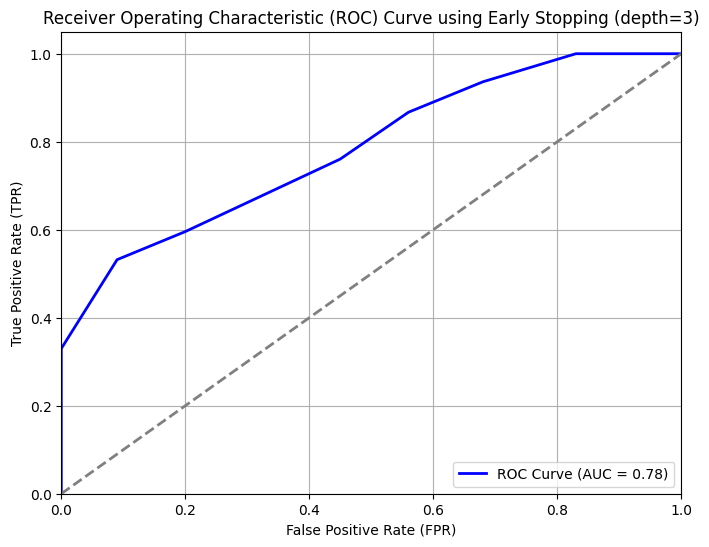

In [160]:
# Predict probabilities for the positive class (class 1)
y_scores_dp = clf_dp.predict_proba(X_test)[:, 1]

# Assuming 'negative' is mapped to 0 and 'positive' is mapped to 1
y_test_dp_binary = np.where(y_test == 'positive', 1, 0)

# Compute ROC curve and ROC area for each class
fpr_dp, tpr_dp, _ = roc_curve(y_test_dp_binary, y_scores_dp)
roc_auc_dp = auc(fpr_dp, tpr_dp)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_dp, tpr_dp, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc_dp:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve using Early Stopping (depth=3)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

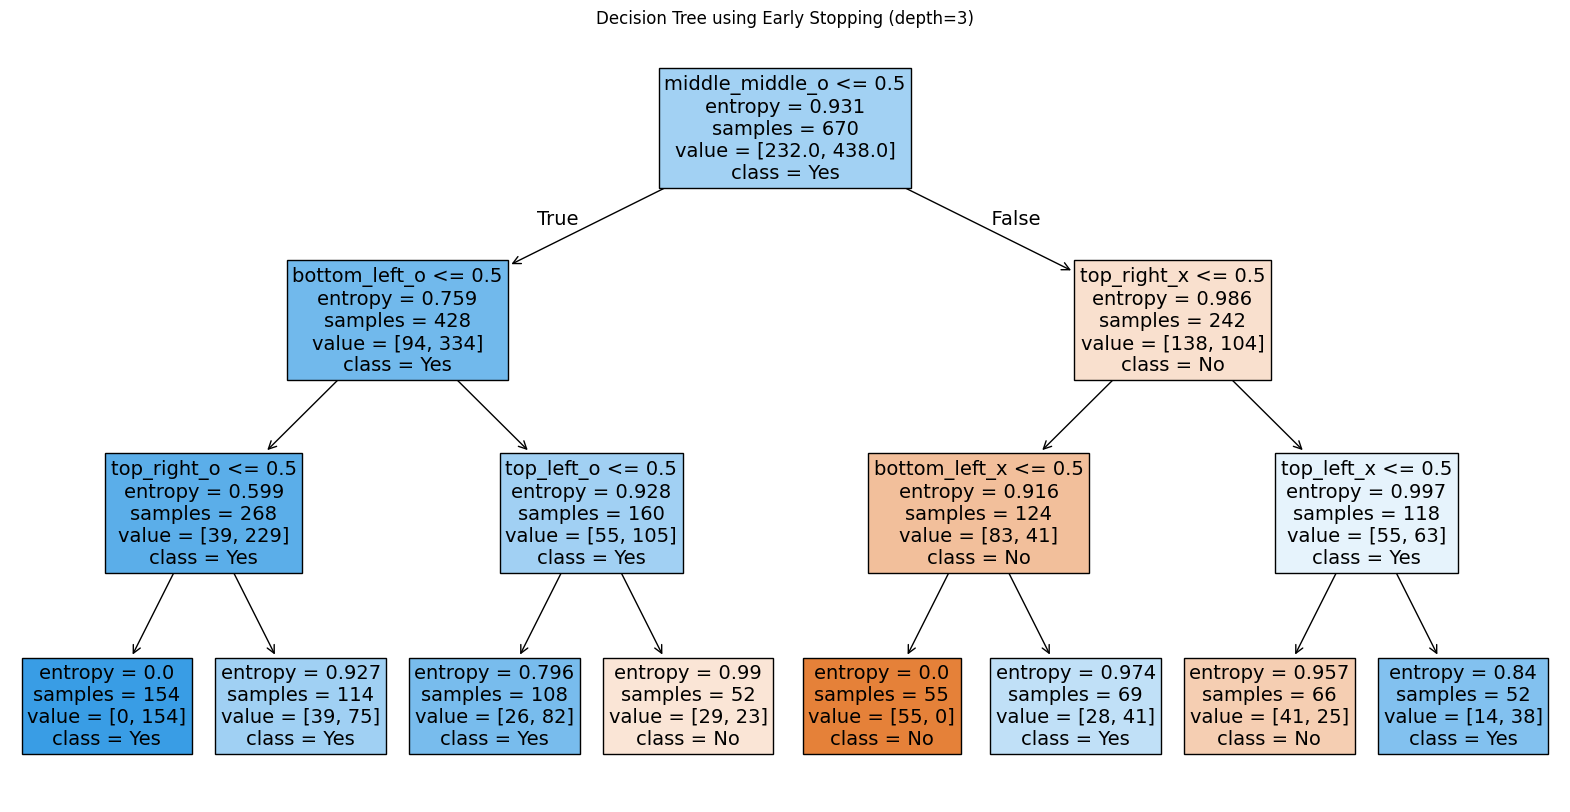

In [161]:
plt.figure(figsize=(20, 10))
tree.plot_tree(clf_dp, feature_names=X.columns, class_names=['No', 'Yes'], filled=True, fontsize =14)
plt.title('Decision Tree using Early Stopping (depth=3)')
# plt.savefig('depth17.png', dpi=200)  # Save the plot as an image
plt.show()

# Cost Complexity Pruning

In [162]:
# Train a decision tree classifier and get the path for cost complexity pruning
clf = DecisionTreeClassifier(random_state=42, criterion='entropy')
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]  # Exclude the maximum alpha


In [163]:
from sklearn.model_selection import cross_val_score
# Cross-validate to find the best alpha
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, criterion='entropy', ccp_alpha=ccp_alpha)
    scores = cross_val_score(clf, X_train, y_train, cv=5)
    clfs.append((ccp_alpha, np.mean(scores), np.std(scores)))


In [164]:

# Convert results to a DataFrame for easier visualization
clfs_df = pd.DataFrame(clfs, columns=['ccp_alpha', 'mean_cv_score', 'std_cv_score'])



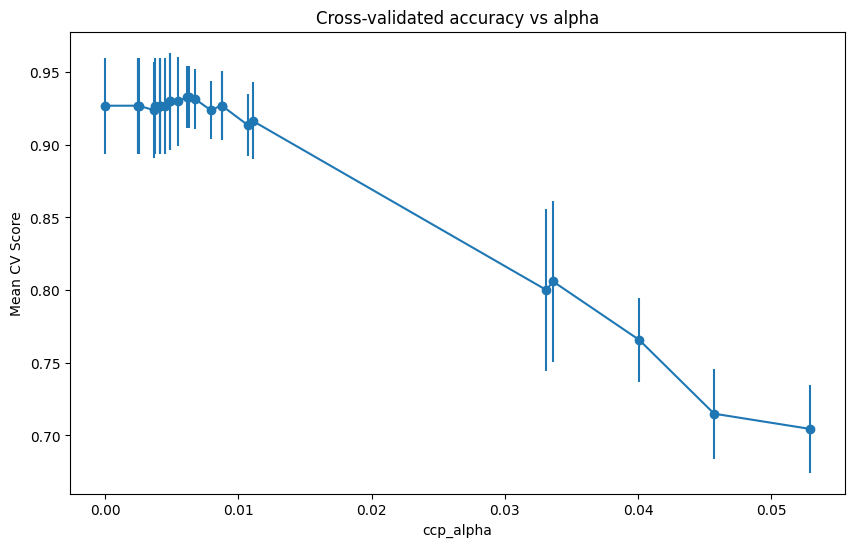

In [165]:
# Plot the cross-validated accuracy against alpha
plt.figure(figsize=(10, 6))
plt.errorbar(clfs_df['ccp_alpha'], clfs_df['mean_cv_score'], yerr=clfs_df['std_cv_score'], fmt='-o')
plt.xlabel('ccp_alpha')
plt.ylabel('Mean CV Score')
plt.title('Cross-validated accuracy vs alpha')
plt.show()



In [166]:
# Find the best alpha
best_alpha = clfs_df.loc[clfs_df['mean_cv_score'].idxmax()]['ccp_alpha']
print(f"Best ccp_alpha: {best_alpha}")

Best ccp_alpha: 0.006146977921255705


In [167]:
clf_cc = DecisionTreeClassifier( criterion='entropy', ccp_alpha=best_alpha)  # Set the ccp_alpha parameter
#ccp_alpha = non-negative scalar

In [168]:
clf_cc.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.006146977921255705, criterion='entropy')

In [169]:
y_pred_cc = clf_cc.predict(X_test)
y_pred_cc

array(['positive', 'positive', 'positive', 'negative', 'positive',
       'negative', 'negative', 'positive', 'positive', 'positive',
       'positive', 'positive', 'negative', 'positive', 'positive',
       'negative', 'positive', 'positive', 'negative', 'positive',
       'positive', 'negative', 'negative', 'positive', 'positive',
       'positive', 'negative', 'positive', 'negative', 'positive',
       'negative', 'negative', 'positive', 'negative', 'positive',
       'positive', 'positive', 'positive', 'negative', 'positive',
       'negative', 'positive', 'negative', 'positive', 'positive',
       'positive', 'negative', 'positive', 'positive', 'positive',
       'negative', 'positive', 'negative', 'positive', 'negative',
       'positive', 'negative', 'positive', 'positive', 'positive',
       'positive', 'positive', 'positive', 'positive', 'negative',
       'positive', 'positive', 'positive', 'positive', 'negative',
       'positive', 'positive', 'positive', 'negative', 'negati

In [170]:
for pred, true in zip(y_pred_cc, y_test):
    print(f"Predicted: {pred} and Ground: {true}") 

Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: negative and Ground: negative
Predicted: positive and Ground: positive
Predicted: negative and Ground: negative
Predicted: negative and Ground: negative
Predicted: positive and Ground: positive
Predicted: positive and Ground: negative
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: negative and Ground: positive
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: negative and Ground: negative
Predicted: positive and Ground: positive
Predicted: positive and Ground: positive
Predicted: negative and Ground: negative
Predicted: positive and Ground: positive
Predicted: positive and Ground: negative
Predicted: negative and Ground: negative
Predicted: negative and Ground: positive
Predicted: positive and Ground: positive
Predicted: posit

In [171]:
confusion_mat_cc = confusion_matrix(y_test, y_pred_cc)
print(confusion_mat_cc)

[[ 84  16]
 [ 12 176]]


In [172]:
confusion_df_cc = pd.DataFrame(confusion_mat_cc, index=['No', 'Yes'],columns=['No','Yes'])

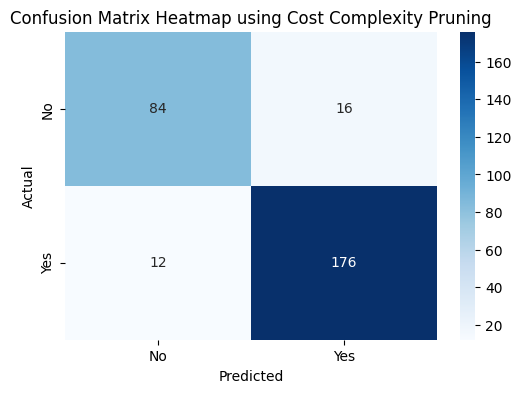

In [173]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_df_cc, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap using Cost Complexity Pruning')
# plt.savefig('confusion_matrix_maxdepth17.png',dpi=200)  # Save the plot as an image
plt.show()

In [174]:
report_cc = classification_report(y_test, y_pred_cc)
print("Classification report for Cost Complexity Pruning")
print(report_cc)

Classification report for Cost Complexity Pruning
              precision    recall  f1-score   support

    negative       0.88      0.84      0.86       100
    positive       0.92      0.94      0.93       188

    accuracy                           0.90       288
   macro avg       0.90      0.89      0.89       288
weighted avg       0.90      0.90      0.90       288



In [175]:
# Calculate F1 score
f1_cc = f1_score(y_test, y_pred_cc, pos_label='positive')

# Calculate accuracy
accuracy_cc = accuracy_score(y_test, y_pred_cc)

# Calculate precision
precision_cc = precision_score(y_test, y_pred_cc, pos_label='positive')

# Calculate recall
recall_cc = recall_score(y_test, y_pred_cc, pos_label='positive')

print("F1 Score:", f1_cc)
print("Accuracy:", accuracy_cc)
print("Precision:", precision_cc)
print("Recall:",recall_cc)

F1 Score: 0.9263157894736842
Accuracy: 0.9027777777777778
Precision: 0.9166666666666666
Recall: 0.9361702127659575


In [176]:
y_pred_train_cc = clf_cc.predict(X_train)
train_f1_score_cc = f1_score(y_train, y_pred_train_cc, average='weighted')
test_f1_score_cc = f1_score(y_test, y_pred_cc, average='weighted')

print('Train F1 score = ')
print(train_f1_score_cc)
print('Test F1 score = ')
print(test_f1_score_cc)

Train F1 score = 
0.9683969972637991
Test F1 score = 
0.9022974101921469


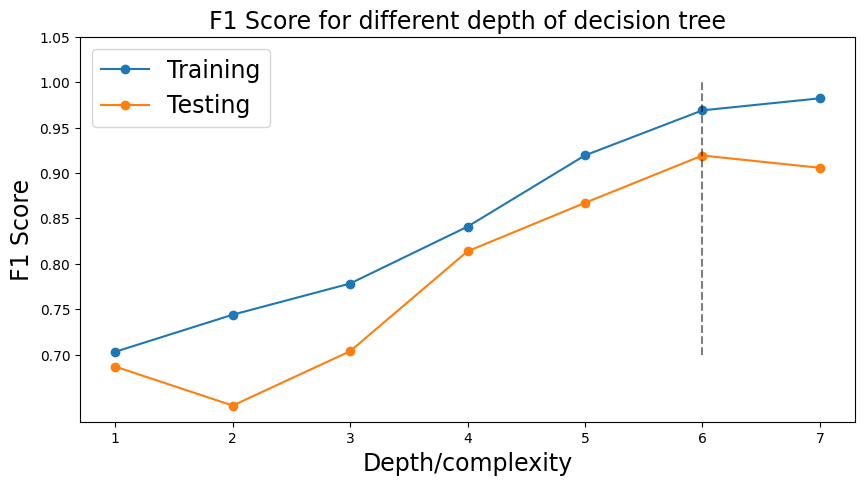

In [177]:
train_scores_cc = []
test_scores_cc = []
for i in range(1, clf_cc.get_depth()+1):
    model_cc = DecisionTreeClassifier(random_state=42, max_depth=i).fit(X_train, y_train)

    # Computing f1_score in train set
    y_pred_train_cc = model_cc.predict(X_train)
    train_scores_cc.append(f1_score(y_pred_train_cc, y_train, average='weighted'))# f1_score on train set

    # Computing f1_score on test set
    y_pred_cc = model_cc.predict(X_test) # Making Predictions
    test_scores_cc.append(f1_score(y_test, y_pred_cc, average='weighted'))

max_test_score_cc = np.argmax(test_scores_cc) + 1
# Plot of depth vs accuracy
depth = clf_cc.get_depth()
plt.figure(figsize = (10,5))
plt.plot(np.arange(1, depth+1, 1), train_scores_cc, marker = 'o', label = 'Training')
plt.plot(np.arange(1, depth+1, 1), test_scores_cc, marker = 'o', label = "Testing")
plt.plot([max_test_score_cc,max_test_score_cc], [0.7, 1.0], '--', color = 'black', alpha = 0.5)
plt.xlabel("Depth/complexity", fontsize = 17)
plt.ylabel("F1 Score", fontsize = 17)
plt.title("F1 Score for different depth of decision tree", fontsize = 17)
plt.xticks(np.arange(1, depth+1, 1))
plt.yticks(np.arange(0.7, 1.05, 0.05))
plt.legend(fontsize = 17)
plt.show()

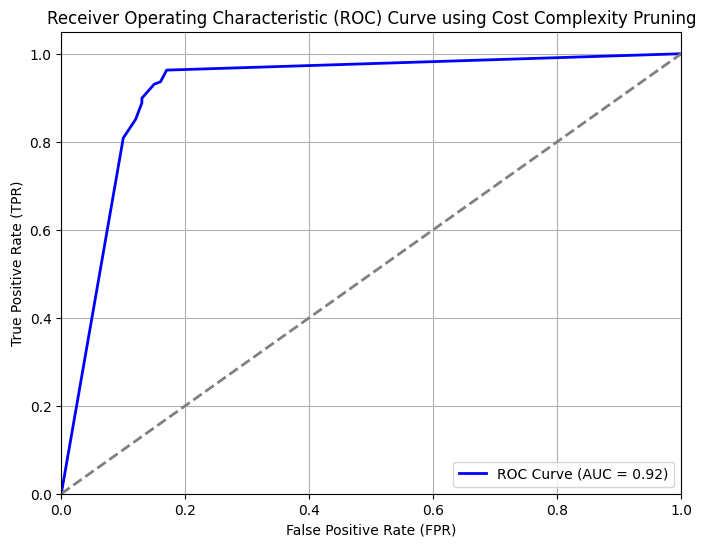

In [178]:
# Predict probabilities for the positive class (class 1)
y_scores_cc = clf_cc.predict_proba(X_test)[:, 1]

# Assuming 'negative' is mapped to 0 and 'positive' is mapped to 1
y_test_cc_binary = np.where(y_test == 'positive', 1, 0)

# Compute ROC curve and ROC area for each class
fpr_cc, tpr_cc, _ = roc_curve(y_test_cc_binary, y_scores_cc)
roc_auc_cc = auc(fpr_cc, tpr_cc)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_cc, tpr_cc, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc_cc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve using Cost Complexity Pruning')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Text(0.5, 1.0, 'Decision Tree using Cost Complexity Pruning')

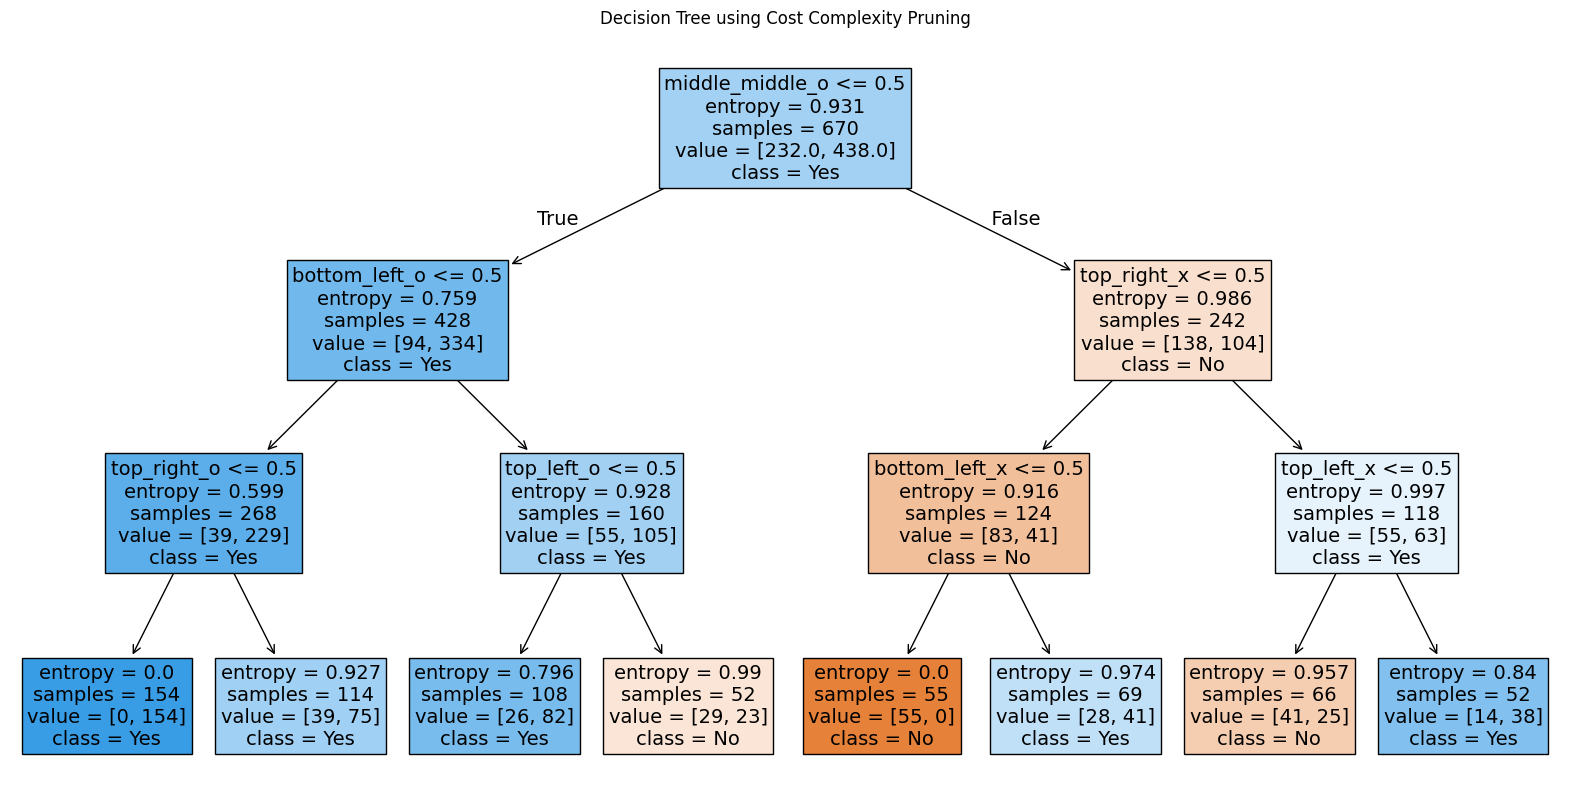

In [179]:
plt.figure(figsize=(20, 10))
tree.plot_tree(clf_dp, feature_names=X.columns, class_names=['No', 'Yes'], filled=True, fontsize =14)
plt.title('Decision Tree using Cost Complexity Pruning')
# plt.savefig

# Comparison

### F1-score plots

### Accuracy plots

### Precision plots

### Recall plots

# Miscellaneous

In [180]:
# path = clf.cost_complexity_pruning_path(X_train, y_train)
# ccp_alphas, impurities = path.ccp_alphas, path.impurities
# ccp_alphas = sorted(ccp_alphas)
# candidate_alphas = [ccp_alphas[i] for i in range(0, 2416, 100)]
# candidate_alphas = candidate_alphas[:-2]

# clfs = []
# for ccp_alpha in candidate_alphas:
#     clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
#     clf.fit(X_train, y_train)
#     clfs.append(clf)


# train_scores = [f1_score(clf.predict(X_train), y_train, average='weighted') for clf in clfs]
# test_scores = [f1_score(clf.predict(X_test), y_test, average='weighted') for clf in clfs]

In [181]:
# plt.figure(figsize = (10,5))
# plt.xlabel("alpha")
# plt.ylabel("f1 score")
# plt.title("F1 Score vs alpha for training and testing sets")
# plt.plot(candidate_alphas, train_scores, marker='o', label="train", drawstyle="steps-post")
# plt.plot(candidate_alphas, test_scores, marker='o', label="test", drawstyle="steps-post")
# plt.legend()
# plt.show()